<a href="https://colab.research.google.com/github/uddipta-deka/multiclass-brain-tumor-detection/blob/main/notebooks/2_Baseline_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [3]:
BASE_PATH = "/content/drive/MyDrive/Brain Tumor Classification"
TRAIN_PATH = os.path.join(BASE_PATH, "dataset", "Training")
TEST_PATH = os.path.join(BASE_PATH, "dataset", "Testing")

In [4]:
# Image Configuration (Based on EDA finding)
IMG_SIZE = (224, 224)
CHANNELS = 3

BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.001

NUM_CLASSES = 4 ## Glioma, Meningioma, No Tumor, Pituitary

Input Shape ($224 \times 224$):
Standardized resolution to ensure compatibility with future Transfer Learning architectures (ResNet50).

Batch Size ($32$): Balanced to optimize GPU memory usage while maintaining stable gradient estimates.

Learning Rate ($0.001$): Standard starting point for the Adam optimizer to ensure smooth convergence.
.

In [5]:
train_datagen = ImageDataGenerator(
 rescale=1./255,
 validation_split=0.2
)

test_datagen = ImageDataGenerator(
rescale=1./255
)

# 2. Training Subset
train_generator = train_datagen.flow_from_directory(
TRAIN_PATH,
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode='categorical',
subset='training'
)

# 3. Validation Subset
val_generator = train_datagen.flow_from_directory(
TRAIN_PATH,
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode='categorical',
subset='validation'
)

# 4. Final Test Set
test_generator = test_datagen.flow_from_directory(
TEST_PATH,
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode='categorical',
shuffle=False
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [6]:
from tensorflow.keras import layers, models

In [7]:
def baseline_model():
    model = models.Sequential([
        #  First Layer: Edge Detection

        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        layers.MaxPooling2D((2, 2)),

        #  Second Layer: Shape Detection

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        #  Third Layer: Complex Feature Detection

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),


        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        #Output Layer
        layers.Dense(4, activation='softmax')
    ])

    return model


model = baseline_model()


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

SAVE_PATH = os.path.join(BASE_PATH, 'models')
os.makedirs(SAVE_PATH, exist_ok=True)


callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(os.path.join(SAVE_PATH, 'baseline_model.keras'), save_best_only=True)
]


history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 902s 6s/step - accuracy: 0.6371 - loss: 0.9011 - val_accuracy: 0.7188 - val_loss: 0.6863
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - accuracy: 0.8033 - loss: 0.5062 - val_accuracy: 0.8125 - val_loss: 0.4714
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 338s 2s/step - accuracy: 0.8623 - loss: 0.3872 - val_accuracy: 0.8616 - val_loss: 0.3591
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.8998 - loss: 0.2827 - val_accuracy: 0.8705 - val_loss: 0.3202
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 328s 2s/step - accuracy: 0.9201 - loss: 0.2127 - val_accuracy: 0.8991 - val_loss: 0.2739
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 370s 2s/step - accuracy: 0.9342 - loss: 0.1859 - val_accuracy: 0.9098 - val_loss: 0.2590
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 310s 2s/step - accuracy: 0.9471 - loss: 0.1578 - val_accuracy: 0.9080 - val_loss: 0.2639
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 307s 2s/step - accuracy: 0.9554 - loss: 0.1191 - val_accu

## Model Performance Analysis

* **Optimal Convergence:** Reached at Epoch 9 ($val\_loss: 0.2236, val\_accuracy: 93.12\%$).
* **Termination:** Training stopped at Epoch 14 as the validation loss failed to improve for 5 consecutive epochs.
* **Weights Restoration:** The model has been reverted to the weights from Epoch 9 to ensure peak generalization.

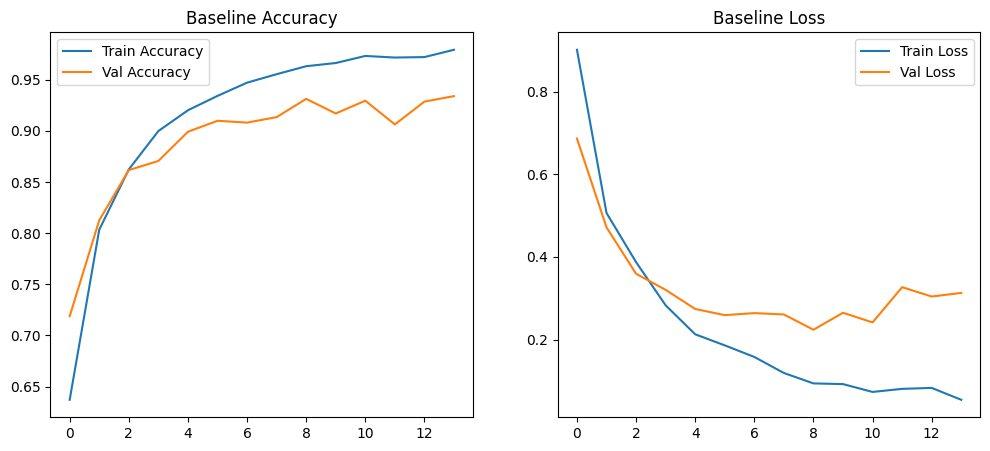

In [10]:
# Plot Training vs Validation Results
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Baseline Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Baseline Loss')
plt.legend()

plt.show()

In [11]:
model = tf.keras.models.load_model(os.path.join(SAVE_PATH, 'baseline_model.keras'))

print("Using the BEST weights for Confusion Matrix and Classification Report!")

Using the BEST weights for Confusion Matrix and Classification Report!


50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 883ms/step


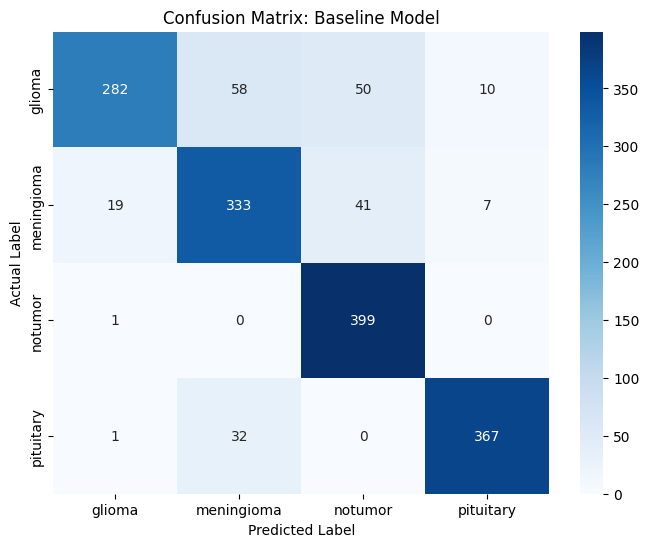

              precision    recall  f1-score   support

      glioma       0.93      0.70      0.80       400
  meningioma       0.79      0.83      0.81       400
     notumor       0.81      1.00      0.90       400
   pituitary       0.96      0.92      0.94       400

    accuracy                           0.86      1600
   macro avg       0.87      0.86      0.86      1600
weighted avg       0.87      0.86      0.86      1600



In [16]:
from sklearn.metrics import confusion_matrix, classification_report


labels = list(train_generator.class_indices.keys())

test_generator.reset()
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(test_generator.classes, y_pred)

#plots
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: Baseline Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

#The Stats Report
print(classification_report(test_generator.classes, y_pred, target_names=labels))

**Baseline Evaluation Summary:**

Overall Accuracy: 86%

Best Performance: The model performs best on the pituitary class, with high precision and recall. This is likely because the features of this class are more distinct.

Weak Area: The glioma class has low recall (0.70), meaning the model misses around 30% of actual glioma cases.

Bias Observation: The model shows a slight tendency to predict “no tumor”, which may cause some tumor cases to be missed.

 **Confusion Matrix Insights:**

Most of the misclassifications occur in the glioma class.

Some tumor images are incorrectly predicted as “no tumor”.

Predictions for the pituitary class are mostly accurate
